In [5]:
# !pip install pandas numpy matplotlib seaborn scikit-learn wordcloud openpyxl -q

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
print('Libraries imported successfully.')


Libraries imported successfully.


In [6]:
FILE_PATH = 'Combined_Single_Excel (1).xlsx'

df = pd.read_excel(FILE_PATH)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 732 rows x 15 columns


,country,day,hashtag,hour,likes,month,plataforms,semtiment,tewetrs,text,Timestamp,user,value_worlds,worlds,Year
0,Czech Republic,18,#Awe #ArchitecturalGrandeur,14,35,8,Facebook,Awe,18,Awe-inspired by the grandeur of an ancient cat...,2018-08-18 14:45:00.000000 UTC,CathedralVisitor,394,390,2018
1,Czech Republic,18,#Awe #ArchitecturalGrandeur,14,35,8,Facebook,Awe,18,Awe-struck by the grandeur of an ancient cathe...,2018-08-18 14:45:00.000000 UTC,CathedralVisitor,414,410,2018
2,China,18,#Awe #EngineeringMarvels,19,35,8,Twitter,Awe,18,"Walking the Great Wall of China, each step a t...",2017-08-18 19:30:00.000000 UTC,GreatWallWalker,509,505,2017
3,Denmark,8,#Euphoria #PuzzleCompletion,15,40,6,Instagram,Euphoria,20,Euphoria floods in as the final puzzle piece c...,2022-06-08 15:30:00.000000 UTC,PuzzleSolver,393,389,2022
4,Denmark,8,#Euphoria #PerfectPuzzle,15,40,6,Instagram,Euphoria,20,Euphoria floods in as the final puzzle piece f...,2022-06-08 15:30:00.000000 UTC,PuzzleSolver,413,409,2022


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       732 non-null    object
 1   day           732 non-null    int64 
 2   hashtag       732 non-null    object
 3   hour          732 non-null    int64 
 4   likes         732 non-null    int64 
 5   month         732 non-null    int64 
 6   plataforms    732 non-null    object
 7   semtiment     732 non-null    object
 8   tewetrs       732 non-null    int64 
 9   text          732 non-null    object
 10  Timestamp     732 non-null    object
 11  user          732 non-null    object
 12  value_worlds  732 non-null    int64 
 13  worlds        732 non-null    int64 
 14  Year          732 non-null    int64 
dtypes: int64(8), object(7)
memory usage: 85.9+ KB


In [8]:
df = df.rename(columns={
    'semtiment': 'sentiment_raw',
    'plataforms': 'platform',
    'tewetrs': 'retweets',
})

print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
country          0
day              0
hashtag          0
hour             0
likes            0
month            0
platform         0
sentiment_raw    0
retweets         0
text             0
Timestamp        0
user             0
value_worlds     0
worlds           0
Year             0
dtype: int64


In [9]:
duplicate_rows = df.duplicated().sum()
duplicate_text = df['text'].duplicated().sum()
print(f"Fully duplicated rows: {duplicate_rows}")
print(f"Posts with duplicate text (different metadata): {duplicate_text}")

# Strip whitespace from string columns
str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce', utc=True)
print(f"\nUnparseable timestamps: {df['Timestamp'].isnull().sum()}")
print(f"Unique raw sentiment/emotion labels: {df['sentiment_raw'].nunique()}")


Fully duplicated rows: 0
Posts with duplicate text (different metadata): 25

Unparseable timestamps: 0
Unique raw sentiment/emotion labels: 191


In [10]:
POSITIVE_EMOTIONS = {
    'Acceptance', 'Accomplishment', 'Admiration', 'Adoration', 'Adrenaline', 'Adventure',
    'Affection', 'Amazement', 'Amusement', 'Anticipation', 'Appreciation', 'Arousal',
    'ArtisticBurst', 'Awe', 'Blessed', 'Breakthrough', 'Calmness', 'Captivation', 'Celebration',
    'Celestial Wonder', 'Charm', 'Colorful', 'Compassion', 'Compassionate', 'Confidence',
    'Confident', 'Connection', 'Contentment', 'Coziness', 'Creative Inspiration', 'Creativity',
    'Culinary Adventure', 'CulinaryOdyssey', 'Curiosity', 'Dazzle', 'DreamChaser', 'Ecstasy',
    'Elation', 'Elegance', 'Empathetic', 'Empowerment', 'Enchantment', 'Energy', 'Engagement',
    'Enjoyment', 'Enthusiasm', 'Envisioning History', 'Euphoria', 'Excitement', 'Exploration',
    'FestiveJoy', 'Free-spirited', 'Freedom', 'Friendship', 'Fulfillment', 'Grandeur', 'Grateful',
    'Gratitude', 'Happiness', 'Happy', 'Harmony', 'Heartwarming', 'Hope', 'Hopeful', 'Hypnotic',
    'Iconic', 'Imagination', 'Immersion', 'InnerJourney', 'Inspiration', 'Inspired', 'Intrigue',
    'Joy', 'Joy in Baking', 'JoyfulReunion', 'Kind', 'Kindness', 'Love', 'Marvel',
    "Nature's Beauty", "Ocean's Freedom", 'Optimism', 'Overjoyed', 'Pensive', 'Playful',
    'PlayfulJoy', 'Positive', 'Positivity', 'Pride', 'Proud', 'Radiance', 'Rejuvenation',
    'Relief', 'Renewed Effort', 'Resilience', 'Reverence', 'Romance', 'Runway Creativity',
    'Satisfaction', 'Serenity', 'Solace', 'Spark', 'Success', 'Surprise', 'Sympathy',
    'Tenderness', 'Thrill', 'Thrilling Journey', 'Touched', 'Tranquility', 'Triumph',
    'Vibrancy', 'Whimsy', 'Wonder', 'Wonderment', 'Zest', 'Mindfulness', 'Motivation',
}

NEGATIVE_EMOTIONS = {
    'Anger', 'Anxiety', 'Apprehensive', 'Bad', 'Betrayal', 'Bitter', 'Bitterness', 'Bittersweet',
    'Boredom', 'Challenge', 'Confusion', 'Darkness', 'Desolation', 'Despair', 'Desperation',
    'Devastated', 'Disappointed', 'Disappointment', 'Disgust', 'Dismissive', 'EmotionalStorm',
    'Embarrassed', 'Envious', 'Envy', 'Exhaustion', 'Fear', 'Fearful', 'Frustrated', 'Frustration',
    'Grief', 'Hate', 'Heartache', 'Heartbreak', 'Helplessness', 'Intimidation', 'Isolation',
    'Jealous', 'Jealousy', 'Loneliness', 'Loss', 'LostLove', 'Melancholy', 'Miscalculation',
    'Mischievous', 'Negative', 'Numbness', 'Obstacle', 'Overwhelmed', 'Pressure', 'Regret',
    'Resentment', 'Ruins', 'Sad', 'Sadness', 'Shame', 'Solitude', 'Sorrow', 'Suffering',
    'Suspense', 'Yearning',
}

NEUTRAL_EMOTIONS = {
    'Ambivalence', 'Contemplation', 'Determination', 'Emotion', 'Indifference', 'Journey',
    'Melodic', 'Mesmerizing', 'Neutral', 'Reflection', 'Whispers of the Past', 'Winter Magic',
    'Nostalgia',
}

def map_sentiment(label):
    label = str(label).strip()
    if label in POSITIVE_EMOTIONS:
        return 'Positive'
    if label in NEGATIVE_EMOTIONS:
        return 'Negative'
    if label in NEUTRAL_EMOTIONS:
        return 'Neutral'
    return 'Unmapped'

df['sentiment'] = df['sentiment_raw'].apply(map_sentiment)

unmapped = df.loc[df['sentiment'] == 'Unmapped', 'sentiment_raw'].unique()
print(f"Unmapped labels remaining: {list(unmapped)}")
print()
print(df['sentiment'].value_counts())


Unmapped labels remaining: []

sentiment
Positive    470
Negative    201
Neutral      61
Name: count, dtype: int64


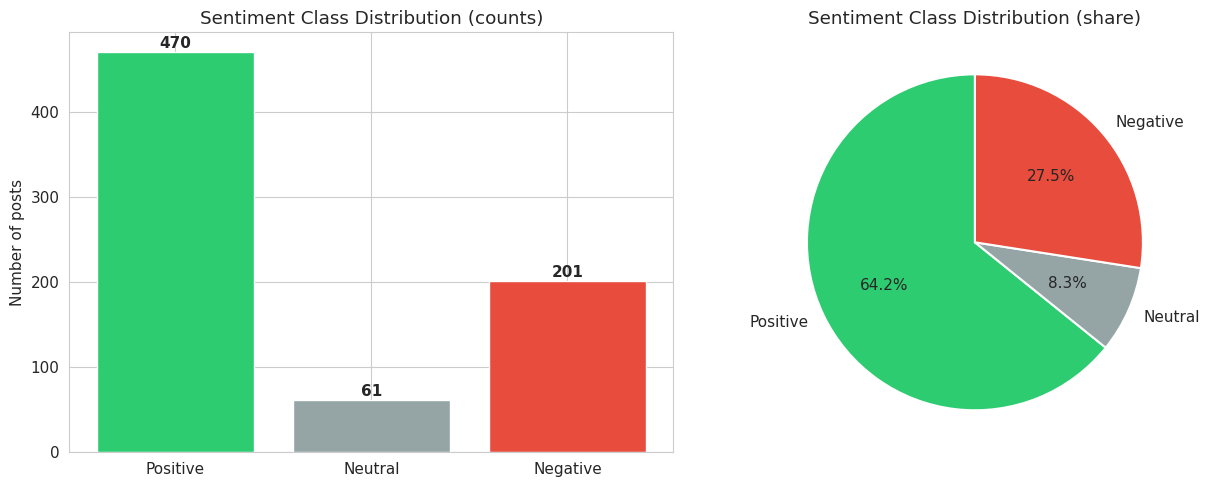

In [11]:
order = ['Positive', 'Neutral', 'Negative']
colors = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df['sentiment'].value_counts().reindex(order)
axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0].set_title('Sentiment Class Distribution (counts)')
axes[0].set_ylabel('Number of posts')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=[colors[c] for c in counts.index], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Sentiment Class Distribution (share)')

plt.tight_layout()
plt.show()


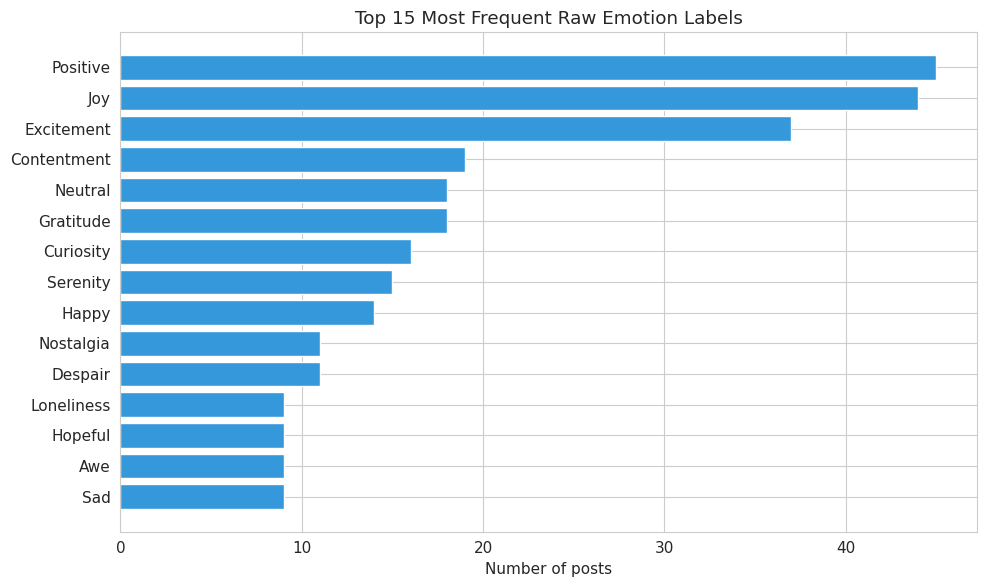

In [12]:
top_emotions = df['sentiment_raw'].value_counts().head(15)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_emotions.index[::-1], top_emotions.values[::-1], color='#3498db')
plt.title('Top 15 Most Frequent Raw Emotion Labels')
plt.xlabel('Number of posts')
plt.tight_layout()
plt.show()


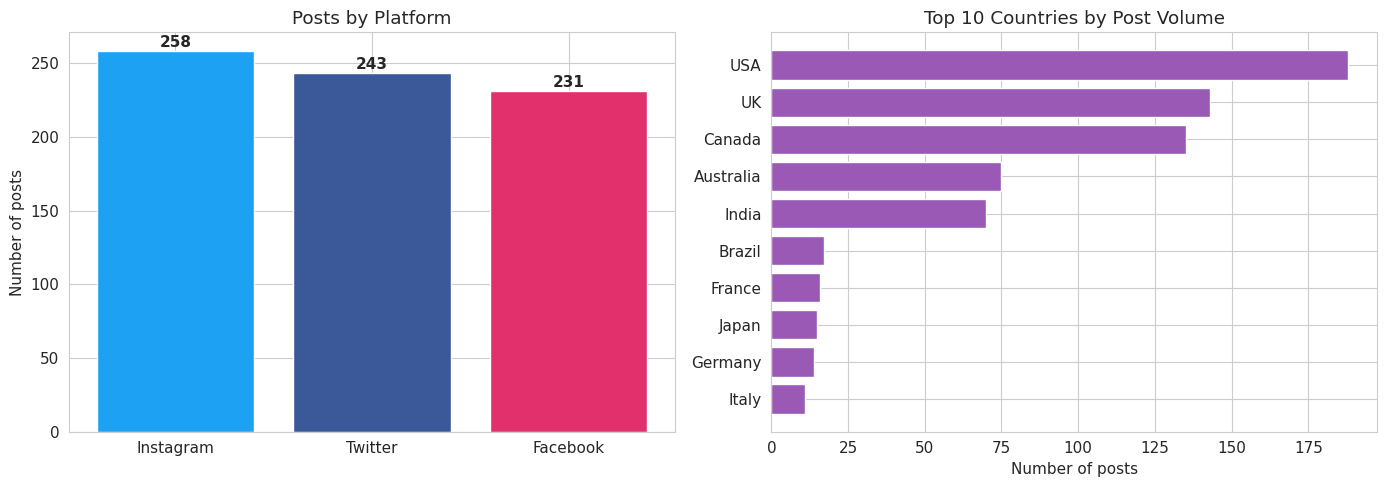

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

platform_counts = df['platform'].value_counts()
axes[0].bar(platform_counts.index, platform_counts.values, color=['#1da1f2', '#3b5998', '#e1306c'])
axes[0].set_title('Posts by Platform')
axes[0].set_ylabel('Number of posts')
for i, v in enumerate(platform_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

top_countries = df['country'].value_counts().head(10)
axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color='#9b59b6')
axes[1].set_title('Top 10 Countries by Post Volume')
axes[1].set_xlabel('Number of posts')

plt.tight_layout()
plt.show()


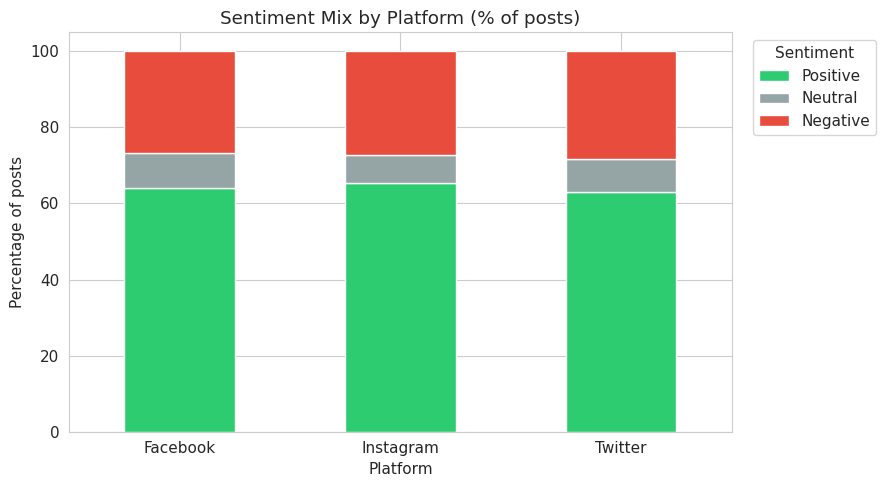

In [14]:
platform_sentiment = pd.crosstab(df['platform'], df['sentiment'], normalize='index')[order] * 100

ax = platform_sentiment.plot(kind='bar', stacked=True, figsize=(9, 5),
                              color=[colors[c] for c in order])
plt.title('Sentiment Mix by Platform (% of posts)')
plt.ylabel('Percentage of posts')
plt.xlabel('Platform')
plt.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


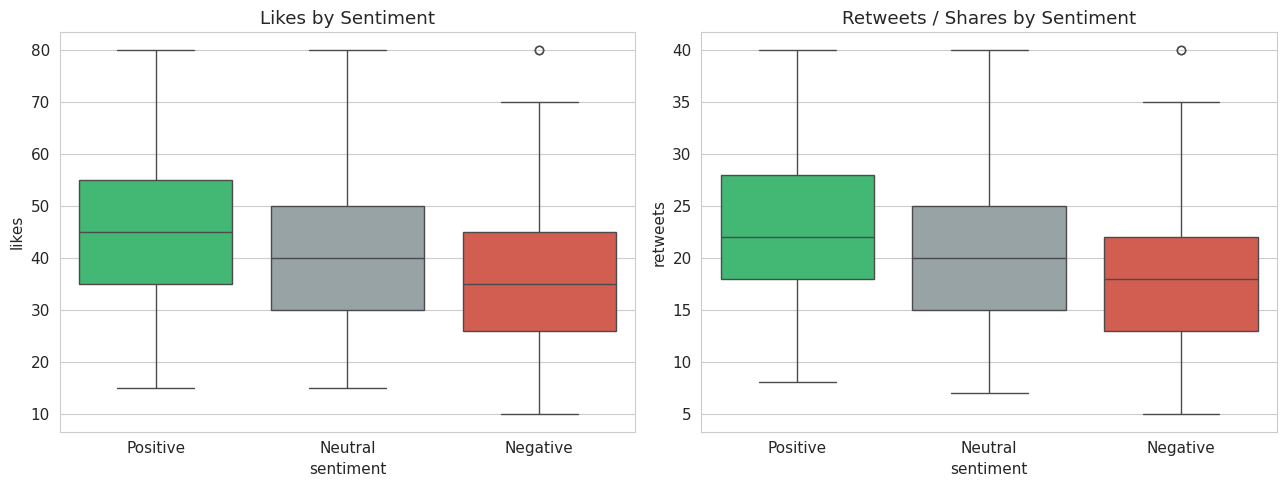

           likes  retweets
sentiment                 
Positive    46.1      23.1
Neutral     40.6      20.4
Negative    36.2      18.2


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x='sentiment', y='likes', order=order, palette=colors, ax=axes[0])
axes[0].set_title('Likes by Sentiment')

sns.boxplot(data=df, x='sentiment', y='retweets', order=order, palette=colors, ax=axes[1])
axes[1].set_title('Retweets / Shares by Sentiment')

plt.tight_layout()
plt.show()

print(df.groupby('sentiment')[['likes', 'retweets']].mean().reindex(order).round(1))


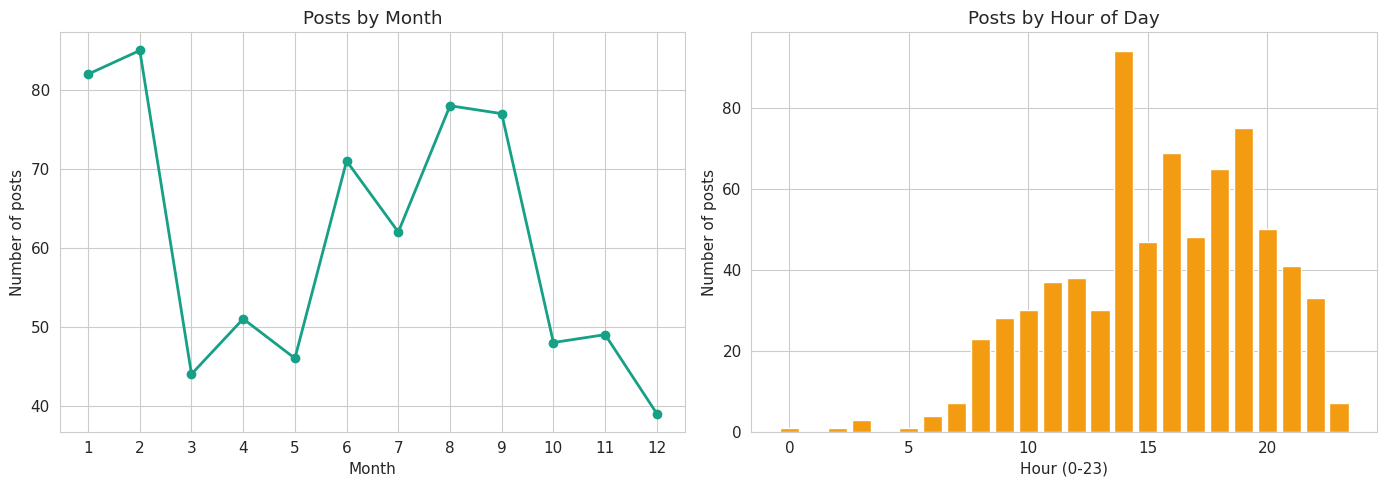

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_counts = df['month'].value_counts().sort_index()
axes[0].plot(month_counts.index, month_counts.values, marker='o', color='#16a085', linewidth=2)
axes[0].set_title('Posts by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of posts')
axes[0].set_xticks(range(1, 13))

hour_counts = df['hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values, color='#f39c12')
axes[1].set_title('Posts by Hour of Day')
axes[1].set_xlabel('Hour (0-23)')
axes[1].set_ylabel('Number of posts')

plt.tight_layout()
plt.show()


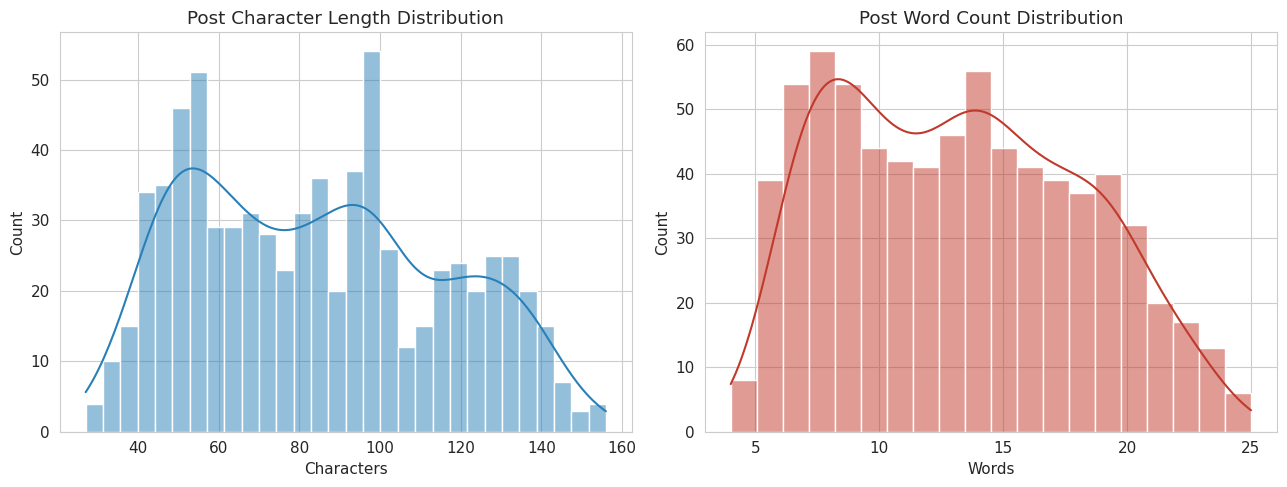

       text_length  word_count
count        732.0       732.0
mean          84.4        13.2
std           31.2         4.9
min           27.0         4.0
25%           56.0         9.0
50%           82.5        13.0
75%          108.0        17.0
max          156.0        25.0


In [17]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['text_length'], bins=30, color='#2980b9', ax=axes[0], kde=True)
axes[0].set_title('Post Character Length Distribution')
axes[0].set_xlabel('Characters')

sns.histplot(df['word_count'], bins=20, color='#c0392b', ax=axes[1], kde=True)
axes[1].set_title('Post Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()

print(df[['text_length', 'word_count']].describe().round(1))


In [18]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)      # URLs
    text = re.sub(r'@\w+', '', text)                    # mentions
    text = re.sub(r'#\w+', '', text)                     # hashtags
    text = re.sub(r"[^a-z\s']", ' ', text)               # punctuation/digits
    text = re.sub(r'\s+', ' ', text).strip()             # extra whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

comparison = df[['text', 'clean_text']].head(5)
for _, row in comparison.iterrows():
    print('RAW:  ', row['text'])
    print('CLEAN:', row['clean_text'])
    print()


RAW:   Awe-inspired by the grandeur of an ancient cathedral's intricate architecture.
CLEAN: awe inspired by the grandeur of an ancient cathedral's intricate architecture

RAW:   Awe-struck by the grandeur of an ancient cathedral's intricate architecture.
CLEAN: awe struck by the grandeur of an ancient cathedral's intricate architecture

RAW:   Walking the Great Wall of China, each step a testament to ancient engineering marvels.
CLEAN: walking the great wall of china each step a testament to ancient engineering marvels

RAW:   Euphoria floods in as the final puzzle piece clicks into place.
CLEAN: euphoria floods in as the final puzzle piece clicks into place

RAW:   Euphoria floods in as the final puzzle piece fits perfectly.
CLEAN: euphoria floods in as the final puzzle piece fits perfectly



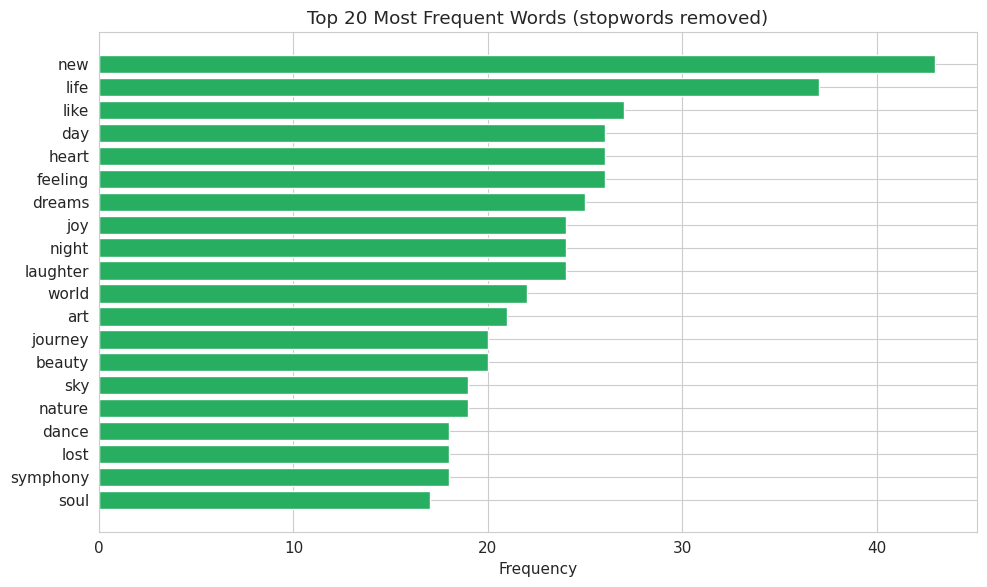

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

count_vec = CountVectorizer(stop_words='english', max_features=20)
word_counts = count_vec.fit_transform(df['clean_text'])
freqs = np.asarray(word_counts.sum(axis=0)).flatten()
word_freq = pd.Series(freqs, index=count_vec.get_feature_names_out()).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(word_freq.index[::-1], word_freq.values[::-1], color='#27ae60')
plt.title('Top 20 Most Frequent Words (stopwords removed)')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()


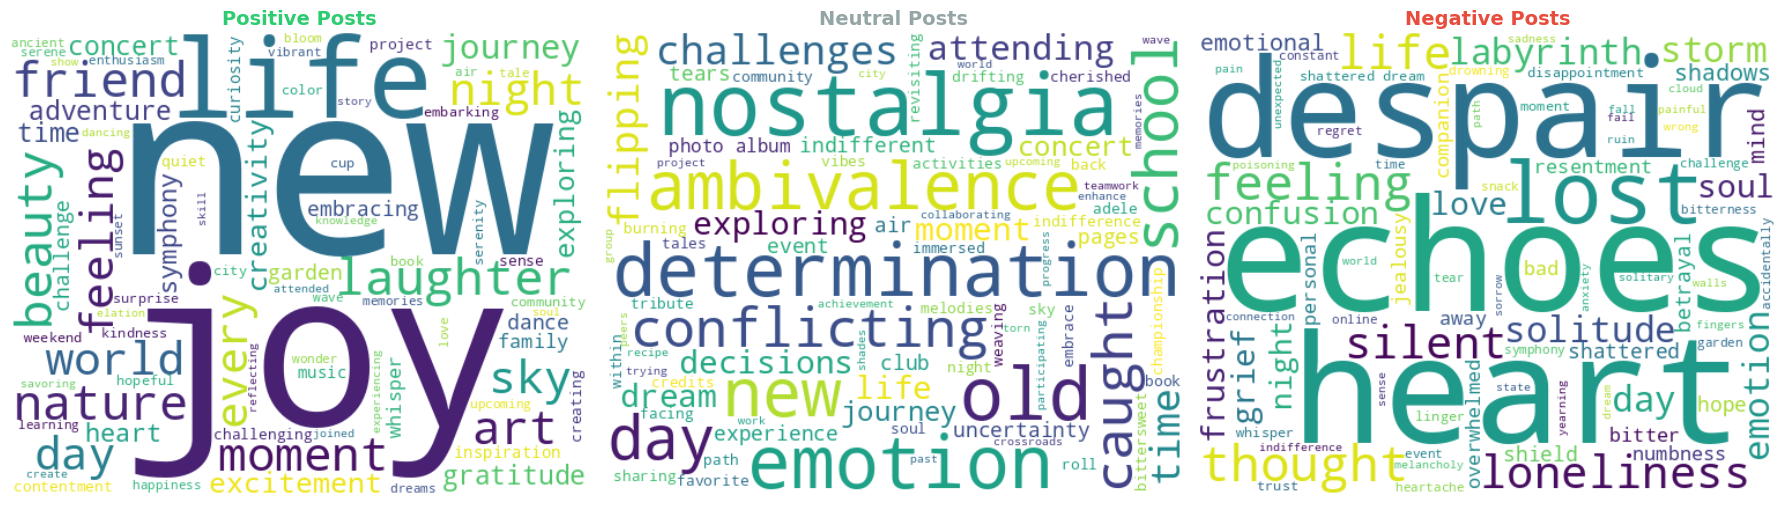

In [20]:
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print("wordcloud package not found — using a built-in matplotlib word-cloud fallback.\n"
          "(Run `pip install wordcloud` for the richer version.)")

def simple_word_cloud(ax, text_blob, title, color, max_words=40):
    """Lightweight word-cloud-style scatter plot using only matplotlib (no extra deps)."""
    from sklearn.feature_extraction.text import CountVectorizer
    cv = CountVectorizer(stop_words='english', max_features=max_words)
    counts = cv.fit_transform([text_blob])
    freqs = np.asarray(counts.sum(axis=0)).flatten()
    words = cv.get_feature_names_out()
    order_idx = np.argsort(freqs)[::-1]
    words, freqs = words[order_idx], freqs[order_idx]

    rng = np.random.RandomState(42)
    placed = []
    max_f = freqs.max() if len(freqs) else 1
    for word, f in zip(words, freqs):
        size = 10 + (f / max_f) * 34
        for _ in range(60):
            x, y = rng.uniform(0.08, 0.92), rng.uniform(0.08, 0.92)
            if all((x - px) ** 2 / 0.22 ** 2 + (y - py) ** 2 / 0.1 ** 2 > 1 for px, py in placed):
                placed.append((x, y))
                break
        else:
            placed.append((x, y))
        alpha = 0.55 + 0.45 * (f / max_f)
        ax.text(x, y, word, fontsize=size, color=color, alpha=alpha,
                ha='center', va='center', fontweight='bold',
                transform=ax.transAxes)
    ax.set_title(title, fontsize=14, fontweight='bold', color=color)
    ax.axis('off')


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, sent in zip(axes, order):
    text_blob = ' '.join(df.loc[df['sentiment'] == sent, 'clean_text'])
    if HAS_WORDCLOUD:
        wc = WordCloud(width=500, height=400, background_color='white',
                        colormap='viridis', max_words=80).generate(text_blob)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{sent} Posts', fontsize=14, fontweight='bold', color=colors[sent])
        ax.axis('off')
    else:
        simple_word_cloud(ax, text_blob, f'{sent} Posts', colors[sent])

plt.tight_layout()
plt.show()


In [21]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} posts")
print(f"Test set:     {X_test.shape[0]} posts")

tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF feature matrix (train): {X_train_tfidf.shape}")
print(f"TF-IDF feature matrix (test):  {X_test_tfidf.shape}")


Training set: 585 posts
Test set:     147 posts

TF-IDF feature matrix (train): (585, 1193)
TF-IDF feature matrix (test):  (147, 1193)


In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Naive Bayes': MultinomialNB(),
    'Linear SVM': LinearSVC(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE),
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {'model': model, 'preds': preds, 'accuracy': acc, 'f1_weighted': f1}
    print(f"{name:22s} | Accuracy: {acc:.3f} | Weighted F1: {f1:.3f}")


Logistic Regression    | Accuracy: 0.912 | Weighted F1: 0.909
Naive Bayes            | Accuracy: 0.816 | Weighted F1: 0.775
Linear SVM             | Accuracy: 0.891 | Weighted F1: 0.885
Random Forest          | Accuracy: 0.810 | Weighted F1: 0.785


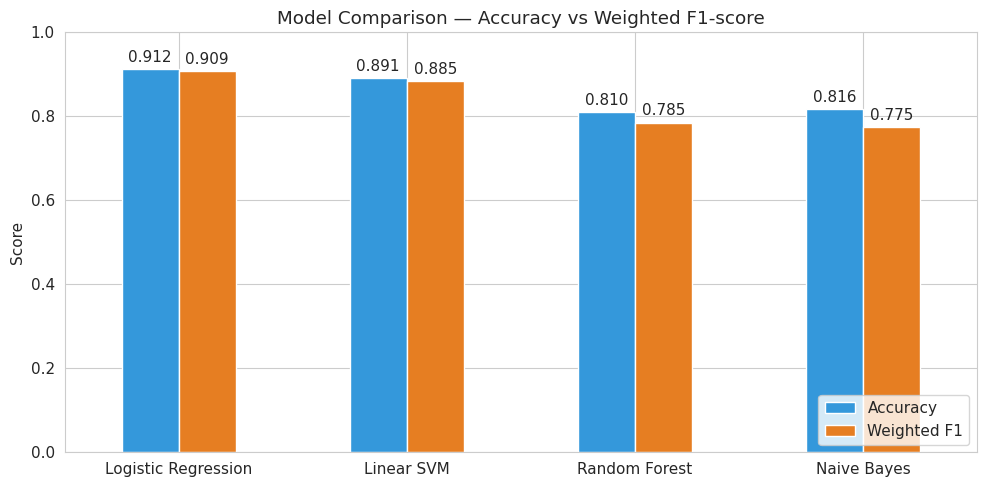

,Accuracy,Weighted F1
Logistic Regression,0.912,0.909
Linear SVM,0.891,0.885
Random Forest,0.810,0.785
Naive Bayes,0.816,0.775


In [23]:
results_df = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Weighted F1': r['f1_weighted']}
    for name, r in results.items()
}).T.sort_values('Weighted F1', ascending=False)

ax = results_df.plot(kind='bar', figsize=(10, 5), color=['#3498db', '#e67e22'], rot=0)
plt.title('Model Comparison — Accuracy vs Weighted F1-score')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

results_df.round(3)


In [24]:
best_name = results_df.index[0]
best_preds = results[best_name]['preds']

print(f"Best model: {best_name}\n")
print(classification_report(y_test, best_preds, target_names=order))


Best model: Logistic Regression

              precision    recall  f1-score   support

    Positive       0.97      0.88      0.92        40
     Neutral       0.78      0.58      0.67        12
    Negative       0.90      0.97      0.93        95

    accuracy                           0.91       147
   macro avg       0.88      0.81      0.84       147
weighted avg       0.91      0.91      0.91       147



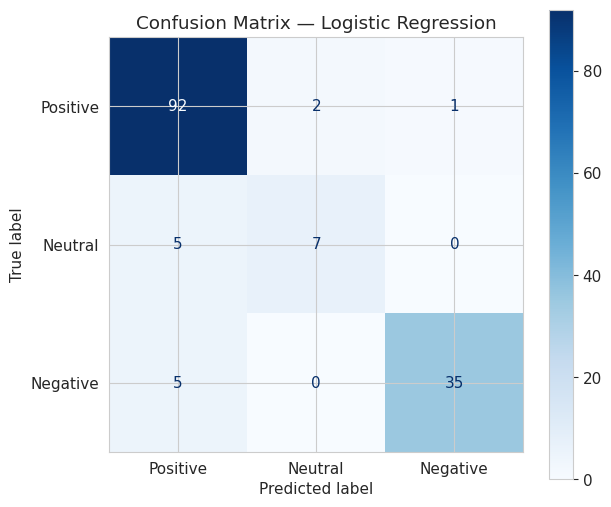

In [25]:
cm = confusion_matrix(y_test, best_preds, labels=order)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()


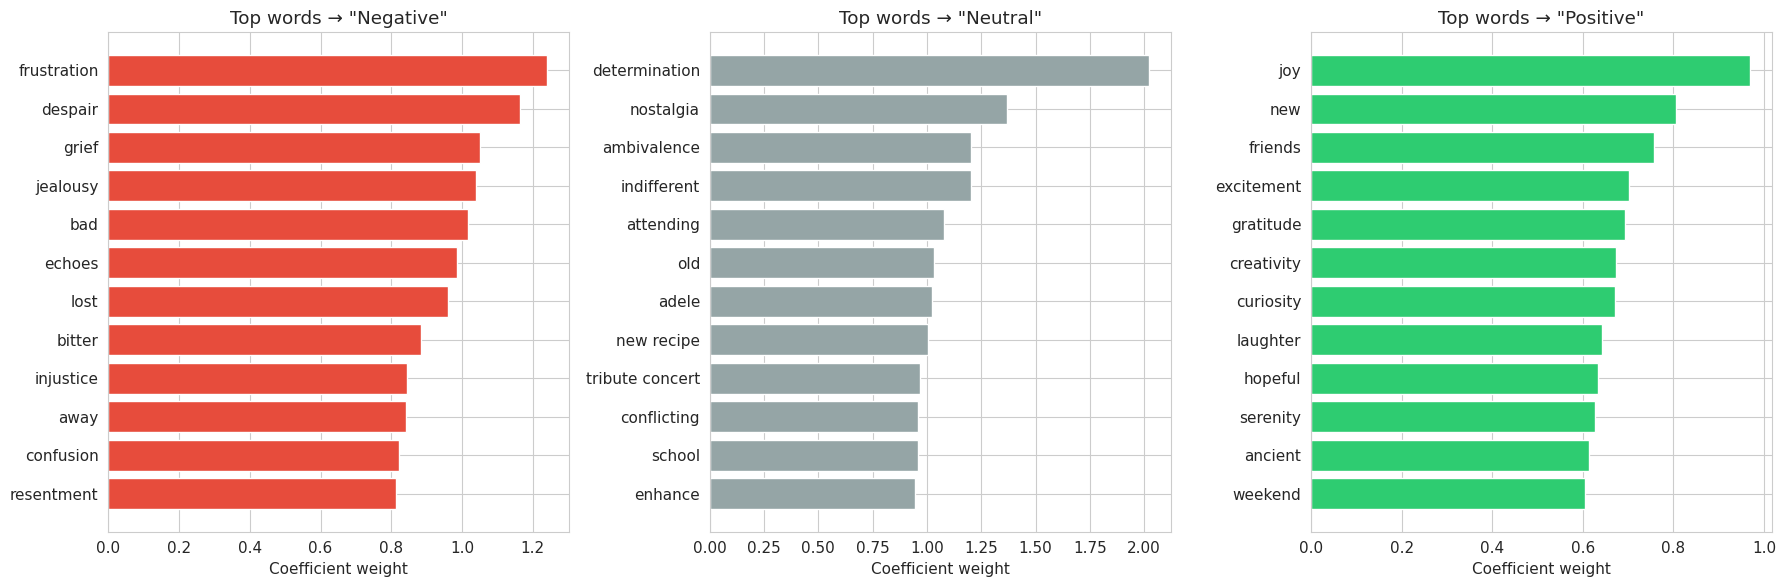

In [26]:
log_reg = results['Logistic Regression']['model']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, class_label in zip(axes, log_reg.classes_):
    class_idx = list(log_reg.classes_).index(class_label)
    coefs = log_reg.coef_[class_idx]
    top_idx = np.argsort(coefs)[-12:]
    ax.barh(feature_names[top_idx], coefs[top_idx], color=colors.get(class_label, '#34495e'))
    ax.set_title(f'Top words → "{class_label}"')
    ax.set_xlabel('Coefficient weight')

plt.tight_layout()
plt.show()


In [27]:
def predict_sentiment(text, model=None, vectorizer=tfidf):
    if model is None:
        model = results[best_name]['model']
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

sample_posts = [
    "Watching the sunrise over the mountains filled me with pure joy and gratitude.",
    "Lost my luggage at the airport and missed my connecting flight. Terrible day.",
    "The museum was okay, nothing particularly memorable about the visit.",
]

for post in sample_posts:
    pred = predict_sentiment(post)
    print(f"[{pred:9s}] {post}")


[Positive ] Watching the sunrise over the mountains filled me with pure joy and gratitude.
[Negative ] Lost my luggage at the airport and missed my connecting flight. Terrible day.
[Positive ] The museum was okay, nothing particularly memorable about the visit.
